In [56]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_parquet("../data/silver/pitches/pitches_2024-04-01.parquet")
df.head()

,game_date,game_pk,pitcher,batter,player_name,pitch_type,pitch_name,release_speed,release_spin_rate,spin_axis,...,strikes,outs_when_up,inning,inning_topbot,stand,p_throws,home_team,away_team,at_bat_number,pitch_number
0,2024-04-01,747218,624647,606466,"González, Victor",SI,Sinker,94.9,2301,112,...,1,2,9,Bot,R,L,AZ,NYY,76,2
1,2024-04-01,747218,624647,606466,"González, Victor",CH,Changeup,87.5,2009,97,...,0,2,9,Bot,R,L,AZ,NYY,76,1
2,2024-04-01,747218,624647,672695,"González, Victor",CH,Changeup,85.9,1988,101,...,1,1,9,Bot,R,L,AZ,NYY,75,3
3,2024-04-01,747218,624647,672695,"González, Victor",SI,Sinker,94.1,2313,116,...,0,1,9,Bot,R,L,AZ,NYY,75,2
4,2024-04-01,747218,624647,672695,"González, Victor",SI,Sinker,93.4,2270,112,...,0,1,9,Bot,R,L,AZ,NYY,75,1


In [8]:
df_cleaned = df.dropna() # Drop NaN rows from df
df_cleaned.shape # DF shape goes from (4190,40) to (678,40)
df_cleaned.head()

,game_date,game_pk,pitcher,batter,player_name,pitch_type,pitch_name,release_speed,release_spin_rate,spin_axis,...,strikes,outs_when_up,inning,inning_topbot,stand,p_throws,home_team,away_team,at_bat_number,pitch_number
0,2024-04-01,747218,624647,606466,"González, Victor",SI,Sinker,94.9,2301,112,...,1,2,9,Bot,R,L,AZ,NYY,76,2
2,2024-04-01,747218,624647,672695,"González, Victor",CH,Changeup,85.9,1988,101,...,1,1,9,Bot,R,L,AZ,NYY,75,3
5,2024-04-01,747218,624647,678489,"González, Victor",SI,Sinker,95.2,2248,117,...,1,1,9,Bot,R,L,AZ,NYY,74,3
8,2024-04-01,747218,624647,672515,"González, Victor",SI,Sinker,93.9,2168,117,...,0,0,9,Bot,R,L,AZ,NYY,73,1
9,2024-04-01,747218,666818,592450,"Frías, Luis",SI,Sinker,95.8,2147,207,...,1,1,9,Top,R,R,AZ,NYY,72,4


Text(0, 0.5, 'Frequency')

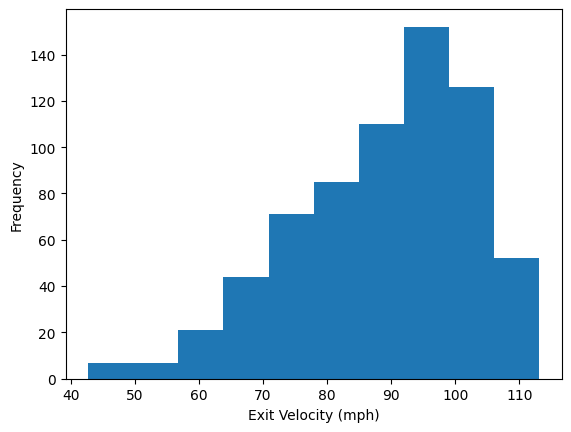

In [21]:
plt.hist(df_cleaned['launch_speed'].where(df_cleaned['launch_speed'] > 40)) # Histogram of exit velocity and its frequency, >40 mph to exclude bunts/noise
plt.xlabel('Exit Velocity (mph)')
plt.ylabel('Frequency')

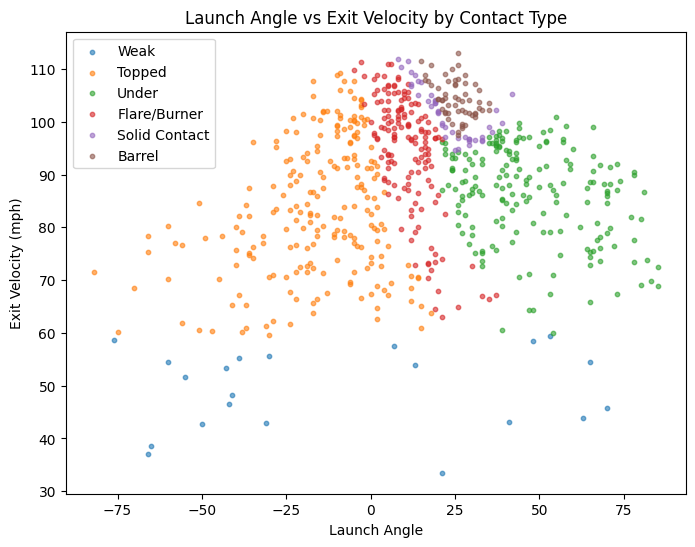

In [22]:
# Scatterplot for Launch Angle vs Exit Velocity

# Map numeric categories to names
contact_labels = {
    1: "Weak",
    2: "Topped",
    3: "Under",
    4: "Flare/Burner",
    5: "Solid Contact",
    6: "Barrel"
}

plt.figure(figsize=(8,6))

# Loop through each category
for value, label in contact_labels.items():
    
    # Filter dataframe for that category
    subset = df_cleaned[df_cleaned["launch_speed_angle"] == value]
    
    # Plot that subset
    plt.scatter(
        subset["launch_angle"],
        subset["launch_speed"],
        label=label,
        alpha=0.6,   # transparency helps with overlap
        s=10         # smaller points = cleaner plot
    )

# Labels + legend
plt.xlabel("Launch Angle")
plt.ylabel("Exit Velocity (mph)")
plt.title("Launch Angle vs Exit Velocity by Contact Type")
plt.legend()

plt.show()

In [34]:
# Create % breakdown of contact rates and plot

launch_angle_counts = df_cleaned.groupby(['launch_speed_angle']).size() # Get counts of each type of contact
percentages = launch_angle_counts / launch_angle_counts.sum() * 100 # Get percentages of each type of contact

percentages = percentages.sort_index()
percentages

launch_speed_angle
1     3.097345
2    32.448378
3    27.286136
4    22.418879
5     6.194690
6     8.554572
dtype: float64

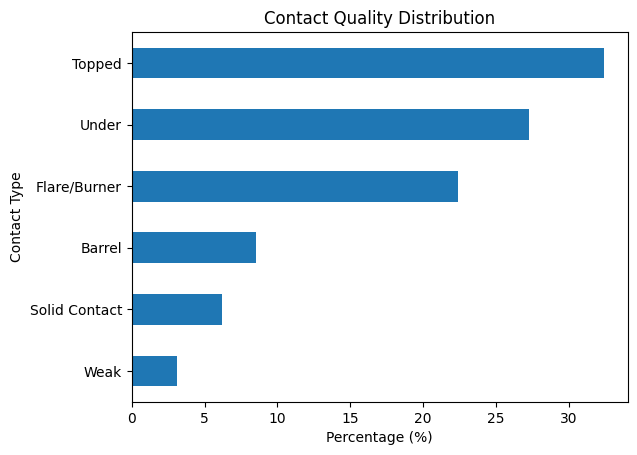

In [ ]:
# Generate bar plot of Contact Breakdown Percentages

label_map = {
    1: "Weak",
    2: "Topped",
    3: "Under",
    4: "Flare/Burner",
    5: "Solid Contact",
    6: "Barrel"
}

percentages = df_cleaned['launch_speed_angle'].value_counts(normalize=True) * 100

# Drop NaNs safely
percentages = percentages.dropna()

# Convert + map
percentages.index = percentages.index.astype(int).map(label_map)

# Plot
percentages.sort_values().plot.barh()

plt.xlabel("Percentage (%)")
plt.ylabel("Contact Type")
plt.title("Contact Quality Distribution")
plt.show()

In [67]:
# Create gold level table for barrel rate (PITCHERS ONLY)

import numpy as np

barrel_df = df_cleaned.dropna(subset=['launch_speed_angle']).copy()

barrel_df['barrel'] = np.where(barrel_df['launch_speed_angle'] == 6, 1, 0)

barrel_stats = barrel_df.groupby('player_name')['barrel'].agg(['sum', 'count'])

barrel_stats = barrel_stats.rename(columns={"sum": "barrels", "count": "total_batted_balls"}) # Rename aggregated columns

barrel_stats['barrel_rate'] = barrel_stats['barrels'] / barrel_stats['total_batted_balls'] # Calculate barrel rate
barrel_stats = barrel_stats[barrel_stats['total_batted_balls'] >= 10] # Get at least 10 batted balls per player for sample size
barrel_stats["barrel_rate_pct"] = (barrel_stats["barrel_rate"] * 100).round(2) # Create clean display column for percentage
barrel_stats = barrel_stats.sort_values("barrel_rate", ascending=False)

barrel_stats.head(10)

,barrels,total_batted_balls,barrel_rate,barrel_rate_pct
player_name,,,,
"Dunning, Dane",4,13,0.307692,30.77
"Manaea, Sean",3,10,0.300000,30.00
"Meyer, Max",3,13,0.230769,23.08
"Muller, Kyle",2,11,0.181818,18.18
"Sánchez, Cristopher",2,11,0.181818,18.18
"Francis, Bowden",3,18,0.166667,16.67
"Imanaga, Shota",2,12,0.166667,16.67
"Wacha, Michael",2,13,0.153846,15.38
"Kremer, Dean",2,16,0.125000,12.50


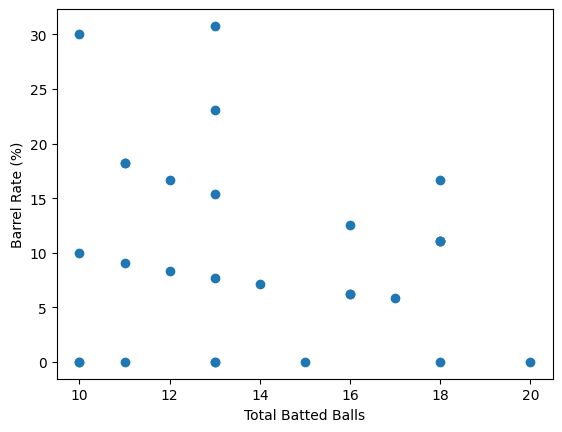

In [72]:
# Generate visual for pitcher barrel rate (Scatter)

x_pitcher = barrel_stats['total_batted_balls'] # Relationship between total batted balls and barrel rate
y_pitcher = barrel_stats['barrel_rate_pct']

plt.scatter(x=x_pitcher, y=y_pitcher)
plt.xlabel('Total Batted Balls')
plt.ylabel('Barrel Rate (%)')
plt.show()

In [69]:
# Create gold level table for barrel rate (HITTERS ONLY)

import numpy as np
from pybaseball import playerid_reverse_lookup

hitter_barrels = df_cleaned.dropna(subset=['launch_speed_angle']).copy()

hitter_barrels['barrel'] = np.where(hitter_barrels['launch_speed_angle'] == 6, 1, 0)

hitter_barrel_stats = hitter_barrels.groupby('batter')['barrel'].agg(['sum', 'count'])

hitter_barrel_stats = hitter_barrel_stats.rename(columns={"sum": "barrels", "count": "total_batted_balls"}) # Rename aggregated columns

hitter_barrel_stats['barrel_rate'] = hitter_barrel_stats['barrels'] / hitter_barrel_stats['total_batted_balls'] # Calculate barrel rate
hitter_barrel_stats = hitter_barrel_stats[hitter_barrel_stats['total_batted_balls'] >= 3] # Get at least 3 batted balls per player for sample size
hitter_barrel_stats["barrel_rate_pct"] = (hitter_barrel_stats["barrel_rate"] * 100).round(2) # Create clean display column for percentage
hitter_barrel_stats = hitter_barrel_stats.sort_values("barrel_rate", ascending=False)

# Get unique batter IDs from your cleaned data
unique_batters = df_cleaned["batter"].dropna().unique()

# Look up batter names using MLBAM IDs
batter_names_df = playerid_reverse_lookup(
    unique_batters,
    key_type="mlbam"
)

# Format names as "Last, First" to match Statcast player_name format
batter_names_df["player_name"] = (
    batter_names_df["name_last"] + ", " + batter_names_df["name_first"]
)

# Merge names onto hitter barrel stats
hitter_barrel_stats = hitter_barrel_stats.merge(
    batter_names_df[["key_mlbam", "player_name"]],
    left_on="batter",
    right_on="key_mlbam",
    how="left"
)

# Drop duplicate ID column from lookup
hitter_barrel_stats = hitter_barrel_stats.drop(columns=["key_mlbam"])

hitter_barrel_stats.head(10)

,barrels,total_batted_balls,barrel_rate,barrel_rate_pct,player_name
0,3,4,0.750000,75.00,"albies, ozzie"
1,2,3,0.666667,66.67,"adams, riley"
2,2,3,0.666667,66.67,"trout, mike"
3,1,3,0.333333,33.33,"pérez, salvador"
4,1,3,0.333333,33.33,"france, ty"
5,1,3,0.333333,33.33,"montero, elehuris"
6,1,3,0.333333,33.33,"mountcastle, ryan"
7,1,3,0.333333,33.33,"peña, jeremy"
8,1,3,0.333333,33.33,"valdez, enmanuel"
9,1,3,0.333333,33.33,"urías, ramón"
